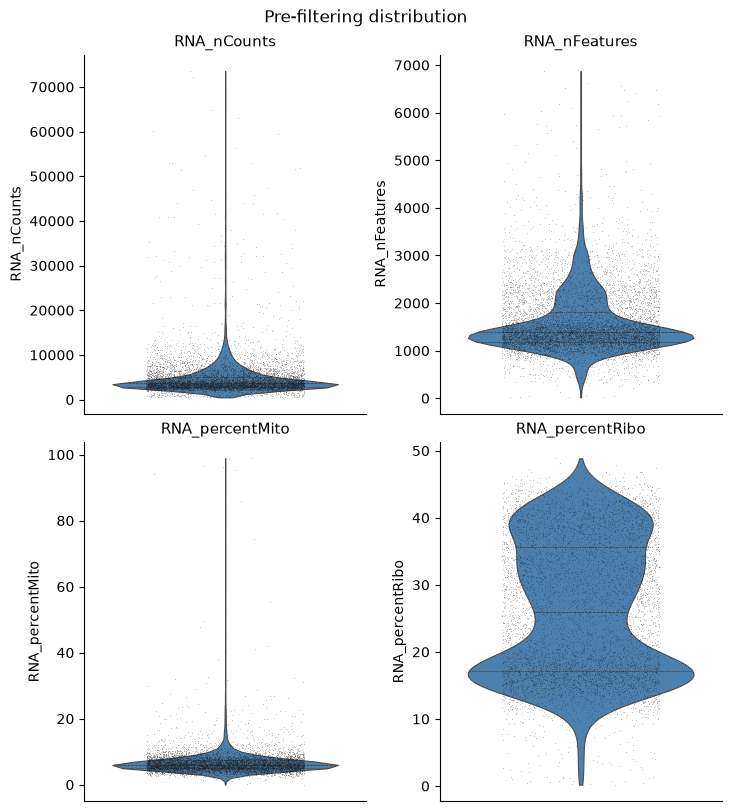

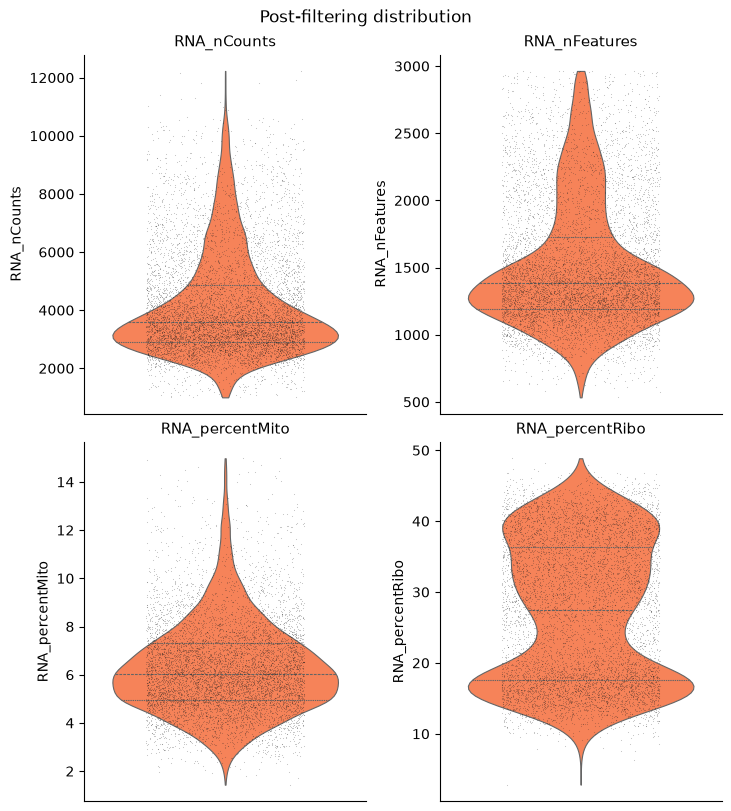

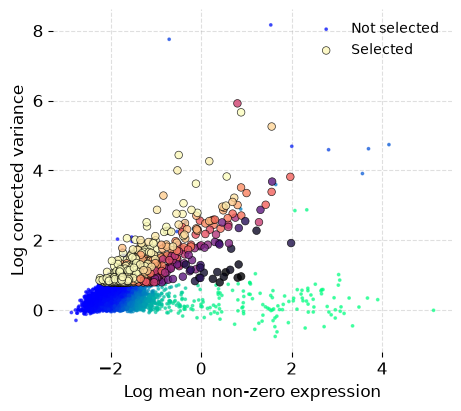

In [1]:
import scarf

scarf.set_verbosity('WARNING')

scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_8K_pbmc_citeseq',
    destination='scarf_datasets',
    zarr=True,
)

ds = scarf.DataStore(
    'scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr',
    default_assay='RNA',
    nthreads=4,
)

ds.auto_filter_cells()

ds.mark_hvgs(
    min_cells=20,
    top_n=1000,
    min_mean=-3,
    max_mean=2,
    max_var=6,
)
ds.make_graph(
    feat_key='hvgs',
    k=21,
    dims=15,
    n_centroids=100,
)
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
)
ds.run_leiden_clustering(resolution=1)

adt_names = ds.ADT.feats.to_pandas_dataframe(['names'])['names']
is_control = adt_names.str.contains('control').values
ds.ADT.feats.update_key(~is_control, 'I')

ds.make_graph(
    from_assay='ADT',
    feat_key='I',
    k=21,
    dims=0,
    n_centroids=100,
)
ds.run_umap(
    from_assay='ADT',
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
)
ds.run_leiden_clustering(
    from_assay='ADT',
    resolution=1,
)

In [2]:
ds.integrate_assays(
    assays=['RNA', 'ADT'],
    label='RNA+ADT',
    method='snn',
)

In [3]:
ds.run_umap(
    integrated_graph='RNA+ADT',
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True
)

ds.run_leiden_clustering(
    integrated_graph='RNA+ADT',
    resolution=1.75
)

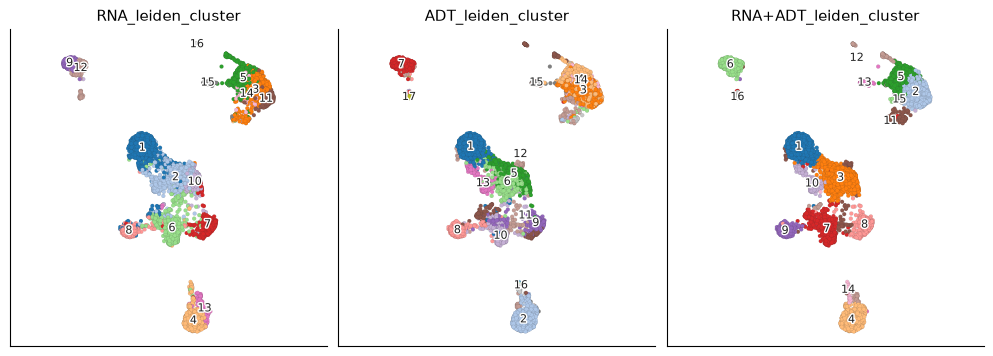

PlotResult(axes=3, tables=0, legends=3, scales=4, owns_figure=True, rendered=True)

In [4]:
ds.plots.embedding(
    layout_key='RNA+ADT_UMAP',
    color_by=[
        'RNA_leiden_cluster',
        'ADT_leiden_cluster',
        'RNA+ADT_leiden_cluster',
    ],
    legend_loc='on_data',
    n_columns=3,
)

In [5]:
ds.cells.columns

['I',
 'ids',
 'names',
 'ADT_nFeatures',
 'RNA_tSNE2',
 'RNA+ADT_UMAP1',
 'RNA_percentMito',
 'ADT_UMAP1',
 'ADT_UMAP2',
 'RNA_tSNE1',
 'ADT_nCounts',
 'RNA_percentRibo',
 'RNA_nFeatures',
 'RNA_cluster',
 'RNA+ADT_leiden_cluster',
 'RNA_nCounts',
 'RNA+ADT_UMAP2',
 'ADT_leiden_cluster',
 'RNA_UMAP2',
 'RNA_leiden_cluster',
 'RNA_UMAP1']

In [6]:
ds.integrate_assays(
    assays=['RNA', 'ADT'],
    label='RNA+ADT_wnn',
    method='wnn'
)

ds.run_umap(
    integrated_graph='RNA+ADT_wnn',
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True
)

ds.run_leiden_clustering(
    integrated_graph='RNA+ADT_wnn',
    resolution=1.75
)

No dimension reduction was used for ADT data. Memory consumption may be high.



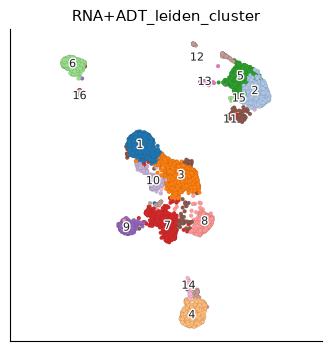

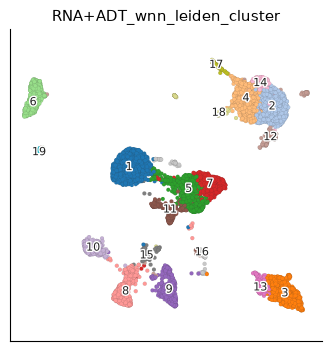

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [7]:
ds.plots.embedding(
    layout_key='RNA+ADT_UMAP',
    color_by='RNA+ADT_leiden_cluster',
    legend_loc='on_data',
)
ds.plots.embedding(
    layout_key='RNA+ADT_wnn_UMAP',
    color_by='RNA+ADT_wnn_leiden_cluster',
    legend_loc='on_data',
)